In [ ]:
import torch  # PyTorchの基本的な機能を含むメインのライブラリ
import torch.nn as nn  # ニューラルネットワークの構築に関連するクラスや関数を含むモジュール
import torch.optim as optim  # 最適化アルゴリズムを含むモジュール
import torchvision  # 一般的なデータセットや事前学習モデルなど、コンピュータビジョンに関するユーティリティを提供
import torchvision.transforms as transforms  # 画像の前処理に関連するクラスや関数を含むモジュール
from torchvision import models  # 事前学習済みモデルや一般的なモデルアーキテクチャを含むモジュール
from torchvision.datasets import ImageFolder # ディレクトリ構造から画像データセットをロードするためのクラス
from torch.utils.data import DataLoader, random_split  # データセットのローディングや分割に関連するユーティリティ

In [ ]:
data_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),         # 画像をランダムに水平反転
    transforms.RandomRotation(10),             # 画像を-10〜10度の範囲でランダムに回転
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # 色のバリエーションをランダムに変更
    transforms.Resize([224,224]),  # 画像のサイズを224x224ピクセルにリサイズ
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [ ]:
dataset_path = "./dataset"  # 対象のデータセットへのパスを設定
dataset = ImageFolder(root=dataset_path, transform=data_transforms)

In [5]:
dataset_len = len(dataset)
train_size = int(0.8 * dataset_len)  # 80%を訓練データに
val_size = dataset_len - train_size  # 残りを検証データに

# データセットをランダムに分割
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [ ]:
device = torch.device('mps')
device # deviceが何に設定されたかを確認

device(type='mps')

ミニバッチサイズ： 4
チャネル数： 3
画像の高さ： 224
画像の幅　： 224
torch.Size([4, 3, 224, 224])


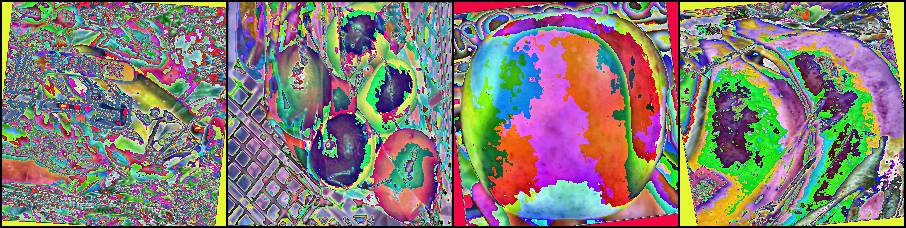

In [ ]:
imgs, _ = next(iter(train_loader))
c, h, w = imgs[0].shape
print("ミニバッチサイズ：", len(imgs))
print("チャネル数：", c)
print("画像の高さ：", h)
print("画像の幅　：", w)
print(imgs.shape)

# グリッド上に並べて1枚の画像にする
img = torchvision.utils.make_grid(imgs)
img = transforms.functional.to_pil_image(img)
display(img)

In [ ]:
NUM_CLASSES = 3 # 分類するクラス数を設定

# ViT base パッチ数16の学習済みモデルを利用
model = models.vit_b_16(weights='DEFAULT')

# 全ての層のパラメータを訓練不可に
for param in model.parameters():
    param.requires_grad = False

# 最後の全結合層をNUM_CLASSES分類用に変更
num_ftrs = model.heads[0].in_features
model.heads[0] = nn.Linear(num_ftrs, NUM_CLASSES)

# GPU上にモデルを移動
model = model.to(device)

In [ ]:
# 多クラス分類のための損失関数の使用準備
criterion = nn.CrossEntropyLoss()

In [ ]:
# モデルのパラメータを更新するためのAdamオプティマイザを初期化し、学習率を0.001に設定する
optimizer = optim.AdamW(model.parameters(), lr=0.001)

Epoch 1/15, Training Loss: 0.979859455426534, Validation Loss: 0.8153008297085762
Epoch 2/15, Training Loss: 0.6623638351758321, Validation Loss: 0.6551865860819817
Epoch 3/15, Training Loss: 0.5355899701515834, Validation Loss: 0.5563022457063198
Epoch 4/15, Training Loss: 0.4526303455233574, Validation Loss: 0.5588920824229717
Epoch 5/15, Training Loss: 0.37405314296483994, Validation Loss: 0.5026343502104282
Epoch 6/15, Training Loss: 0.3463906834522883, Validation Loss: 0.5268402360379696
Epoch 7/15, Training Loss: 0.29269287710388503, Validation Loss: 0.43836966529488564
Epoch 8/15, Training Loss: 0.29859543616573014, Validation Loss: 0.44773710891604424
Epoch 9/15, Training Loss: 0.2895660313467185, Validation Loss: 0.39424424432218075
Epoch 10/15, Training Loss: 0.23230121607581775, Validation Loss: 0.3764204792678356
Epoch 11/15, Training Loss: 0.21550463115175564, Validation Loss: 0.36868871189653873
Epoch 12/15, Training Loss: 0.20024275742471218, Validation Loss: 0.433574618

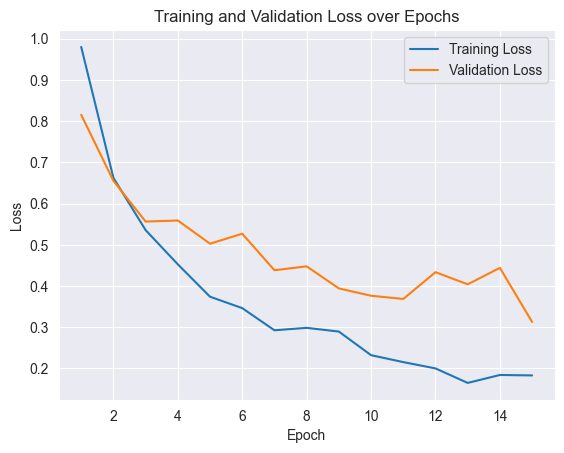

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

train_losses = [] # 訓練時のlossを格納するリスト
val_losses = []   # 検証時のlossを格納するリスト
num_epochs = 15   # 学習回数を15回に設定

# 各エポックでの処理
for epoch in range(num_epochs):
    # モデルを訓練モードに設定
    model.train()
    total_loss = 0.0
    # 訓練データをミニバッチごとに処理
    for i, (images, labels) in enumerate(train_loader):
        # データをGPU等のデバイスに移動
        images, labels = images.to(device), labels.to(device)

        outputs = model(images) # モデルに画像を入力し、予測値を取得
        loss = criterion(outputs, labels) # 損失を計算       
        optimizer.zero_grad() # 勾配を初期化
        loss.backward()  # バックプロパゲーションを実行        
        optimizer.step() # 重みの更新        
        total_loss += loss.item() # 現在のバッチの損失を累積値に追加

    # 平均訓練損失を計算
    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # モデルを評価モードに設定
    model.eval()
    with torch.no_grad():
        total_val_loss = 0.0  
        # 検証データをミニバッチごとに処理
        for images, labels in val_loader:
            # データをGPU等のデバイスに移動
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # モデルに画像を入力し、出力(予測値)を取得
            loss = criterion(outputs, labels) # 損失を計算         
            total_val_loss += loss.item() # 現在のバッチの損失を累積値に追加

    # 平均検証損失を計算
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # エポックごとの訓練と検証の損失を表示
    print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss}, Validation Loss: {avg_val_loss}")

# グラフのスタイルを設定
sns.set_style("darkgrid")
sns.lineplot(x=range(1, num_epochs + 1), y=train_losses, label="Training Loss") # 訓練の損失のグラフを描画
sns.lineplot(x=range(1, num_epochs + 1), y=val_losses, label="Validation Loss") # 検証の損失のグラフを描画
plt.xlabel("Epoch") # x軸のラベルを設定
plt.ylabel("Loss") # y軸のラベルを設定
plt.title("Training and Validation Loss over Epochs") # グラフのタイトルを設定
plt.legend() # 凡例を表示
plt.show() # グラフを表示

In [ ]:
model.eval()  # モデルを評価モードに設定。これにより、DropoutやBatchNormalizationなどの層が推論モードに切り替わる。

correct = 0  # 正しく分類されたサンプルの数を初期化
total = 0    # テストデータのサンプルの総数を初期化

# 勾配の計算を停止。評価時には勾配計算が不要なため、メモリ効率と速度を向上させる。
with torch.no_grad():
    for inputs, labels in val_loader:  # テストデータローダからミニバッチ単位でデータを取得
        inputs, labels = inputs.to(device), labels.to(device)  # データを現在のデバイス（CPU or GPU）に移動
        outputs = model(inputs)  # モデルを使って入力から出力を予測
        _, predicted = torch.max(outputs.data, 1)  # 各サンプルの最大値のインデックスを取得（予測されたクラスを取得）
        total += labels.size(0)  # ミニバッチのサンプル数をトータルカウントに追加
        correct += (predicted == labels).sum().item()  # 予測が正しい場合のカウントを加算

print(f"Accuracy on test set: {100 * correct / total}%")  # テストセットの正解率を計算して表示

Accuracy on test set: 93.33333333333333%


In [ ]:
# モデルの重みを保存　任意のファイル名を付ける
torch.save(model.state_dict(), 'WeightSave/weights_vit.pth')